# 05 — Sentinel-1 comparable-track SAR analysis
**Purpose:** create a homogeneous Sentinel-1 VV/VH monthly record, representative-year maps, and optional pre/post backscatter differences.  
**Inputs:** GLIMS/context ROIs, Earth Engine project ID, and optional verified comparison windows.  
**Outputs:** monthly SAR CSV, backscatter chart, representative-year map, and optional difference map.  
**Runtime:** monthly reductions may take 5–20 minutes; map tiles render on demand.  
**Dependencies:** authenticated Earth Engine account and a registered Cloud project.

## Google Drive and dependencies
The repository is expected at `/content/drive/MyDrive/langtang-glacier-ai`. Earth Engine supplies the imagery; derived artifacts persist in Drive.

In [1]:
from google.colab import drive
drive.mount('/content/drive')
%cd '/content/drive/MyDrive/langtang-glacier-ai'
%pip -q install -r requirements.txt


Mounted at /content/drive
/content/drive/MyDrive/langtang-glacier-ai
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 52.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 102.9 MB/s eta 0:00:00


In [2]:
import os
import sys
from pathlib import Path
ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import ee
import pandas as pd
from src.config import SETTINGS
from src.gee_utils import DATASET_IDS, build_rois, initialize_earth_engine
from src.sar_features import (
    build_monthly_sentinel1_series, diagnose_sentinel1_candidates,
    make_sentinel1_composite, select_sentinel1_candidate,
    sentinel1_difference, sentinel1_features_to_dataframe,
)
from src.utils import ensure_output_directories
from src.visualization import (
    S1_DELTA_VIS, S1_VH_VIS, S1_VV_VIS, make_study_area_map,
    plot_sentinel1_time_series,
)
ensure_output_directories()


In [3]:
EE_PROJECT = os.environ.get('EE_PROJECT') or input('Earth Engine Cloud project ID: ').strip()
if not EE_PROJECT:
    raise ValueError('An Earth Engine-enabled Google Cloud project ID is required.')
try:
    ee.Initialize(project=EE_PROJECT)
except Exception:
    initialize_earth_engine(project=EE_PROJECT, authenticate=True)
print('Earth Engine initialized with:', EE_PROJECT)


Earth Engine Cloud project ID: my-youtube-api-keys-453716
Earth Engine initialized with: my-youtube-api-keys-453716


## Select a homogeneous acquisition track
The code filters to IW mode, 10 m products, and dual VV/VH polarization. It evaluates every pass/orbit candidate using usable glacier coverage, temporal span, and incidence-angle consistency. All subsequent comparisons use the selected track and exclude DEM-screened radar shadow/layover geometry.

In [4]:
rois = build_rois()
candidate_qa_path = SETTINGS.output_qa / 'sentinel1_candidate_track_qa.csv'
if candidate_qa_path.exists():
    candidate_qa = pd.read_csv(candidate_qa_path)
    print('Loaded cached Sentinel-1 candidate QA')
else:
    candidate_qa = diagnose_sentinel1_candidates(rois['glacier_roi'])
    candidate_qa.to_csv(candidate_qa_path, index=False)
track = select_sentinel1_candidate(candidate_qa)
print('Dataset:', DATASET_IDS['sentinel1_grd'])
print('Selected by measured usability:', track)
display(candidate_qa.sort_values('usable_months', ascending=False))


Sentinel-1 QA complete: ASCENDING 85
Sentinel-1 QA complete: DESCENDING 19
Sentinel-1 QA complete: DESCENDING 121
Dataset: COPERNICUS/S1_GRD
Selected by measured usability: {'orbit_pass': 'ASCENDING', 'relative_orbit': 85, 'selection_score': 0.9564135976103476, 'selection_method': 'usable_coverage_temporal_geometry_score'}


,orbit_pass,relative_orbit,total_scenes,first_acquisition,last_acquisition,temporal_coverage_days,event_date,event_source,pre_event_scenes_60d,post_event_scenes_60d,usable_months,median_valid_area_fraction,median_incidence_angle,incidence_angle_p05,incidence_angle_p95
1,DESCENDING,19,326,2016-09-26,2026-08-24,3618,2026-08-26,https://www.esa.int/Applications/Observing_the...,5,0,120,0.979943,33.452755,33.425075,33.793341
0,ASCENDING,85,289,2015-10-30,2026-08-28,3955,2026-08-26,https://www.esa.int/Applications/Observing_the...,5,1,116,0.955847,40.182658,39.908586,40.205206
2,DESCENDING,121,301,2016-10-03,2026-08-31,3618,2026-08-26,https://www.esa.int/Applications/Observing_the...,5,1,9,0.000000,44.445142,44.440783,44.450090


## Monthly glacier-ROI metrics
Each month is a median composite in dB. Empty months remain explicitly missing. Month-to-month differences are descriptive changes in backscatter—not displacement, deformation, or a physical mechanism.

In [5]:
monthly_composites, monthly_features = build_monthly_sentinel1_series(
    rois['glacier_roi'], track
)
sar_monthly = sentinel1_features_to_dataframe(monthly_features)
sar_path = SETTINGS.output_tables / 'sentinel1_monthly_sar_metrics.csv'
sar_monthly.to_csv(sar_path, index=False)
display(sar_monthly.tail(18))
print('Saved:', sar_path)


,angle_deg,date,mean_valid_observation_count,missing_data_flag,orbit_pass,relative_orbit,scene_count,valid_area_fraction,vh_db,vh_std_db,vv_db,vv_std_db,is_complete_period,period_completeness,expected_observation_count,observation_count,quality_status,quality_reason,vv_change_db,vh_change_db
116,40.182941,2025-03-01,2.00000,0,ASCENDING,85,2,0.955847,-16.574479,7.503024,-9.606726,8.281974,True,0.955847,<NA>,2.00000,GOOD,VV/VH and ROI coverage pass requirements,-1.417721,-2.319865
117,40.185835,2025-04-01,3.00000,0,ASCENDING,85,3,0.955847,-15.926832,6.913438,-9.009649,7.825725,True,0.955847,<NA>,3.00000,GOOD,VV/VH and ROI coverage pass requirements,0.597077,0.647647
118,40.194702,2025-05-01,1.00000,0,ASCENDING,85,1,0.955847,-17.515862,7.159224,-9.785475,8.136397,True,0.955847,<NA>,1.00000,GOOD,VV/VH and ROI coverage pass requirements,-0.775825,-1.589030
119,40.220594,2025-06-01,3.00000,0,ASCENDING,85,3,0.955728,-19.115019,7.109206,-10.351510,8.134100,True,0.955728,<NA>,3.00000,GOOD,VV/VH and ROI coverage pass requirements,-0.566035,-1.599157
120,40.222765,2025-07-01,2.00000,0,ASCENDING,85,2,0.955728,-19.091286,7.288014,-9.950074,8.138476,True,0.955728,<NA>,2.00000,GOOD,VV/VH and ROI coverage pass requirements,0.401436,0.023733
121,40.194460,2025-08-01,3.00000,0,ASCENDING,85,3,0.955847,-19.153893,7.245220,-10.009342,8.103012,True,0.955847,<NA>,3.00000,GOOD,VV/VH and ROI coverage pass requirements,-0.059269,-0.062607
122,40.187063,2025-09-01,2.00000,0,ASCENDING,85,2,0.955847,-19.416177,7.001601,-10.270838,8.007567,True,0.955847,<NA>,2.00000,GOOD,VV/VH and ROI coverage pass requirements,-0.261496,-0.262284
123,40.179682,2025-10-01,3.00000,0,ASCENDING,85,3,0.955847,-17.326241,7.379350,-9.569747,8.106914,True,0.955847,<NA>,3.00000,GOOD,VV/VH and ROI coverage pass requirements,0.701091,2.089936
124,40.192450,2025-11-01,3.00000,0,ASCENDING,85,3,0.955847,-15.487442,6.844723,-8.810652,7.805048,True,0.955847,<NA>,3.00000,GOOD,VV/VH and ROI coverage pass requirements,0.759095,1.838798
125,40.184263,2025-12-01,2.00000,0,ASCENDING,85,2,0.955847,-13.548252,6.639721,-7.653638,7.586612,True,0.955847,<NA>,2.00000,GOOD,VV/VH and ROI coverage pass requirements,1.157015,1.939191


Saved: /content/drive/MyDrive/langtang-glacier-ai/outputs/tables/sentinel1_monthly_sar_metrics.csv


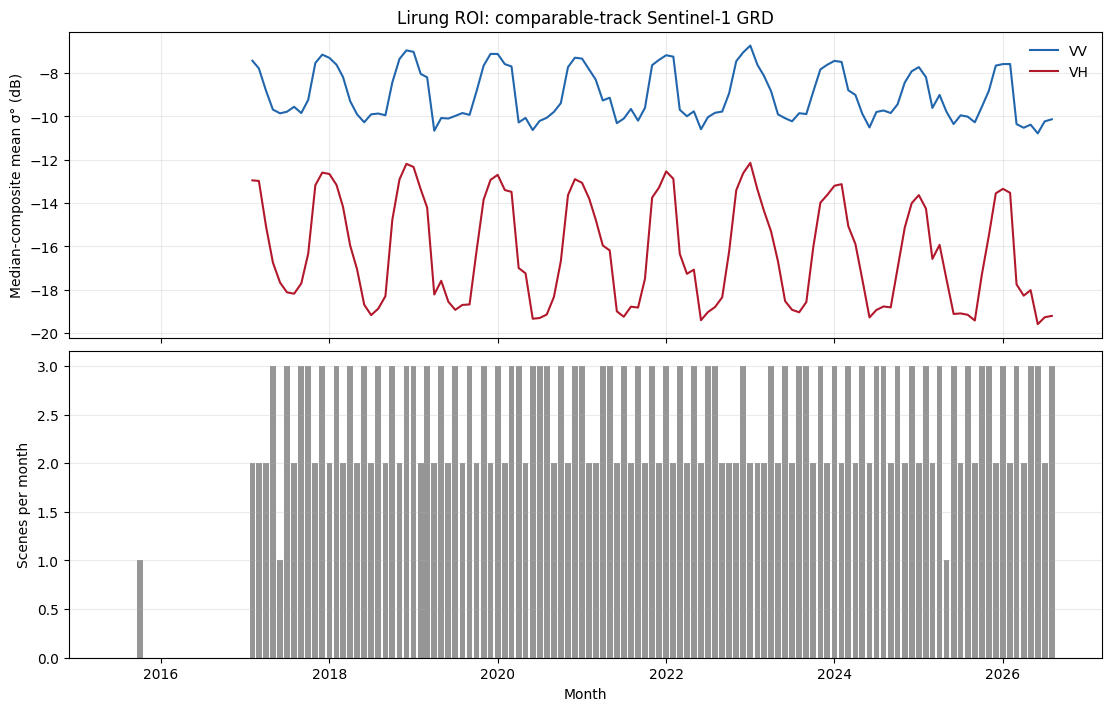

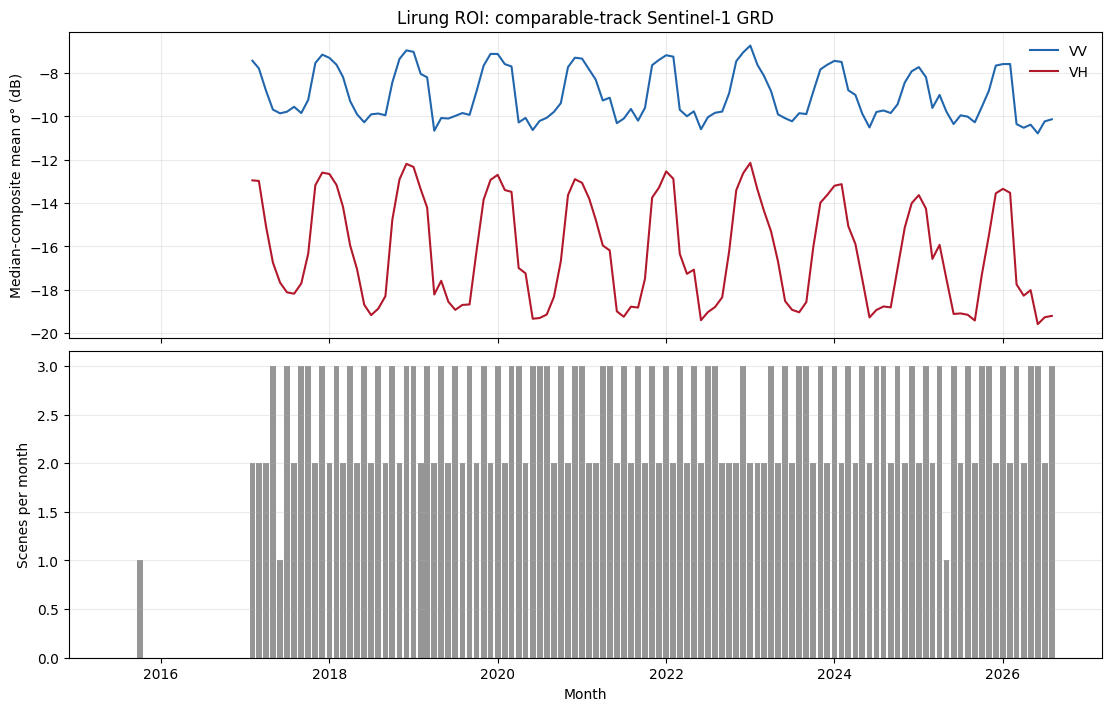

In [6]:
sar_figure = plot_sentinel1_time_series(
    sar_monthly, SETTINGS.output_charts / 'sentinel1_backscatter_timeseries.png'
)
sar_figure


## Representative post-monsoon maps
These use the same October–November window and selected track for each representative year. Toggle VV/VH layers and inspect radar shadow, layover-prone slopes, seams, and coverage.

In [7]:
sar_map = make_study_area_map(rois)
for year in SETTINGS.sentinel1_representative_years:
    image = make_sentinel1_composite(
        rois['context_roi'], f'{year}-10-01', f'{year}-12-01', track
    )
    sar_map.addLayer(image.select('VV'), S1_VV_VIS, f'VV Oct–Nov {year}', year == SETTINGS.sentinel1_representative_years[-1])
    sar_map.addLayer(image.select('VH'), S1_VH_VIS, f'VH Oct–Nov {year}', False)
sar_map.to_html(str(SETTINGS.output_maps / 'sentinel1_representative_years.html'))
sar_map


Map(center=[28.251882136909924, 85.54672799144113], controls=(WidgetControl(options=['position', 'transparent_…

## Optional verified pre/post comparison
Leave all values as `None` until defensible dates are documented. Earth Engine `filterDate` uses an exclusive end date. The difference is `post − pre` in dB and is only a change-screening layer.

In [8]:
PRE_START = None   # e.g. 'YYYY-MM-DD'
PRE_END = None     # exclusive
POST_START = None
POST_END = None    # exclusive

if all((PRE_START, PRE_END, POST_START, POST_END)):
    pre, post, delta = sentinel1_difference(
        rois['context_roi'], PRE_START, PRE_END, POST_START, POST_END, track
    )
    change_map = make_study_area_map(rois)
    change_map.addLayer(pre.select('VV'), S1_VV_VIS, 'Pre VV', False)
    change_map.addLayer(post.select('VV'), S1_VV_VIS, 'Post VV', True)
    change_map.addLayer(delta.select('delta_VV'), S1_DELTA_VIS, 'Delta VV (post - pre)', False)
    change_map.addLayer(delta.select('delta_VH'), S1_DELTA_VIS, 'Delta VH (post - pre)', False)
    change_map.to_html(str(SETTINGS.output_maps / 'sentinel1_pre_post_change.html'))
    display(change_map)
else:
    print('Pre/post analysis skipped: provide four verified window dates.')


Pre/post analysis skipped: provide four verified window dates.


## Scientific interpretation checkpoint
Earth Engine GRD is calibrated, orthorectified σ° in dB, but radiometric terrain flattening is not applied. Himalayan relief causes layover, foreshortening, shadow, and illumination effects. Median composites reduce speckle but do not remove terrain artifacts. Backscatter changes may reflect moisture, snow state, roughness, geometry, or coverage. This notebook does not process phase and therefore performs no InSAR deformation analysis.